# 📊 Eksplorasi Data Intervensi Stunting
Notebook ini digunakan untuk melakukan eksplorasi data awal terhadap dataset intervensi stunting tahun 2023 yang telah diberi label efektivitas (`skor`). Tujuan utama eksplorasi ini adalah untuk memahami distribusi skor, menganalisis alokasi anggaran, dan mengelompokkan data ke dalam kategori-kategori yang dapat digunakan dalam tahap modeling.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
print("Current working directory:", os.getcwd())

Current working directory: d:\Kuliah\Kuliah Semester 12\Skripsi 2025\conda_test\skripsi_stunting\notebooks


## 📥 Load Dataset
Membaca file CSV yang telah diberi label efektivitas.

In [28]:
df = pd.read_csv("../data/stunting_2023_labeled.csv")
print("DataFrame shape:", df.shape)
print("DataFrame columns:", df.columns)

DataFrame shape: (75264, 73)
DataFrame columns: Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'a._Total_Remaja_Putri', 'b._Remaja_Putri_Status_Gizi_Normal_di_desa',
       'c._Remaja_Putri_Status_Anemia_(Hb)_di_desa',
       'Total_Calon_Pengantin_dan_calon_Pasangan_usia_Subur_di_desa',
       'a._Total_Ibu_Hamil', 'b._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Normal',
       'c._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Kesesahan_KEK',
       'a._Jumlah_Bayi_Usia_0-59_Bulan',
       'b._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Normal',
       'c._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Kurang',
       'd._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Buruk',
       'e._Jumlah_Bayi_Usia_0-59_Bulan_Status_Stunting',
       'a._Total_Keluarga_Beresiko_Stunting_dan_Keluarga_rentan',
       'b._Jumlah_Keluarga_Kategori_Rentan',
       'a._Jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb)',
       'b._Jumlah_Remaja_P

## 📈 Distribusi Skor Efektivitas
Menampilkan histogram dari kolom `skor` untuk melihat persebaran desa berdasarkan skor efektivitas.

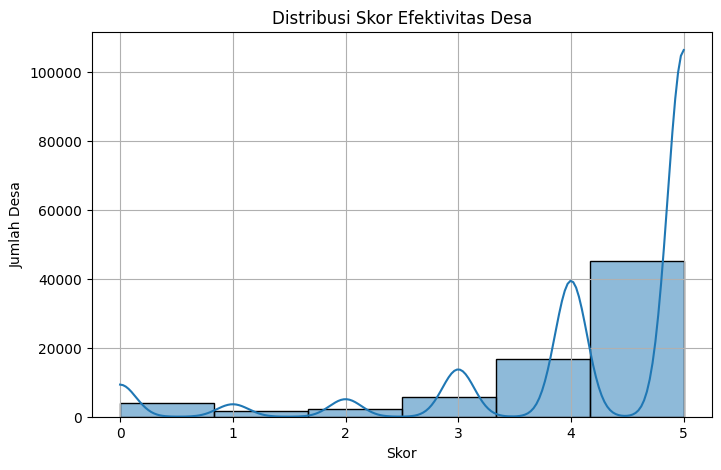

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df['skor'], bins=6, kde=True)
plt.title("Distribusi Skor Efektivitas Desa")
plt.xlabel("Skor")
plt.ylabel("Jumlah Desa")
plt.grid(True)
plt.show()

## 💵 Analisis Statistik dan Kategori Anggaran
Menganalisis statistik deskriptif kolom anggaran dan membaginya ke dalam kategori `rendah`, `sedang`, dan `tinggi` menggunakan `qcut`.

In [30]:

# 1. Nilai minimum
min_anggaran = df["Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting"].min()

# 2. Statistik deskriptif (min, Q1, median, Q3, max, mean, std)
stats = df["Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting"].describe()

print("Nilai anggaran minimum:", min_anggaran)
print(stats)

# Tentukan jumlah bin aktual yang bisa dibuat
try:
    df['kategori_anggaran'] = pd.qcut(
        df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'],
        q=3,
        labels=['rendah', 'sedang', 'tinggi'],
        duplicates='drop'
    )
except ValueError as e:
    # Hitung jumlah bin aktual
    result = pd.qcut(
        df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'],
        q=3,
        duplicates='drop'
    )
    n_bins = result.cat.categories.size
    print(f"Jumlah bin aktual: {n_bins}")
    # Buat label sesuai jumlah bin aktual
    labels = ['rendah', 'sedang', 'tinggi'][:n_bins]
    df['kategori_anggaran'] = pd.qcut(
        df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'],
        q=3,
        labels=labels,
        duplicates='drop'
    )

Nilai anggaran minimum: 0.0
count    7.376100e+04
mean     3.251648e+07
std      6.874524e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.900000e+07
max      1.811584e+09
Name: Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting, dtype: float64
Jumlah bin aktual: 2


## 🔎 Fokus pada Anggaran Non-Zero
Menganalisis hanya desa yang memiliki anggaran > 0 untuk mendapatkan insight yang lebih akurat terkait alokasi anggaran.

In [31]:
col = 'Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'

# Ambil hanya nilai > 0
non_zero = df[df[col] > 0][col]

# Statistik non-zero
stats_nz = non_zero.describe()
print(stats_nz)

# Contoh: ambang pada median non-zero
median_nz = non_zero.quantile(0.50)
print("Median anggaran (non-zero):", median_nz)

# Atau ambang pada kuartil-3 non-zero
q3_nz = non_zero.quantile(0.75)
print("75th percentile anggaran (non-zero):", q3_nz)


count    3.517000e+04
mean     6.819584e+07
std      8.647775e+07
min      1.000000e+00
25%      1.700000e+07
50%      4.180000e+07
75%      8.561325e+07
max      1.811584e+09
Name: Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting, dtype: float64
Median anggaran (non-zero): 41800000.0
75th percentile anggaran (non-zero): 85613250.0


## 📥 Load Dataset
Membaca file CSV yang telah diberi label efektivitas.

In [32]:
import joblib

# Ensure df is loaded
if 'df' not in globals():
    df = pd.read_csv("../data/stunting_2023_labeled.csv")

# 1. Load model dan encoder
model_rf = joblib.load("../model/random_forest_model.pkl")
model_dt = joblib.load("../model/decision_tree_model.pkl")
le_dict = joblib.load("../model/feature_label_encoders.pkl")
le_label = joblib.load("../model/target_label_encoder.pkl")

# 2. Siapkan fitur kategori sesuai training
dummy_features = [
    'Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun',
    'Aktivitas_rutin_Penyelenggaraan_posyandu_',
    'Terdapat_Pembentukan_RDS/TPPS',
    'Terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas',
    'Terdapat_Pengembangan_Program_Ketahanan_Pangan'
]

# 3. Normalisasi kategori (pastikan fungsi sama dengan training)
def normalize_kategorikal(df, fitur_kategori):
    mapping = {
        "tidak ada": "Tidak Ada",
        "tidak": "Tidak Ada",
        "tdk": "Tidak Ada",
        "0": "Tidak Ada",
        "kosong": "Tidak Ada",
        "ada": "Ada",
        "iya": "Ada",
        "ya": "Ada",
        "1": "Ada",
        "rutin tiap bulan": "Rutin Tiap Bulan",
        "rutin setiap bulan": "Rutin Tiap Bulan",
        "rutin": "Rutin Tiap Bulan"
    }
    for col in fitur_kategori:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace(mapping)
        )
    return df

# Tambahkan fitur jumlah "Ada" pada seluruh fitur dummy
df['jumlah_ada'] = (
    (df[dummy_features] == 'Ada').sum(axis=1) +
    (df[dummy_features] == 'Rutin Tiap Bulan').sum(axis=1)
)

df['monitoring_posyandu'] = (
    df['Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun'].astype(str) + '_' +
    df['Aktivitas_rutin_Penyelenggaraan_posyandu_'].astype(str)
)


Distribusi prediksi Random Forest (test): {2: 15053}
Distribusi prediksi Decision Tree (test): {2: 15053}

F1-score Random Forest (test):
 0               0.000000
1               0.000000
2               0.704895
accuracy        0.544277
macro avg       0.234965
weighted avg    0.383658
Name: f1-score, dtype: float64

F1-score Decision Tree (test):
 0               0.000000
1               0.000000
2               0.704895
accuracy        0.544277
macro avg       0.234965
weighted avg    0.383658
Name: f1-score, dtype: float64


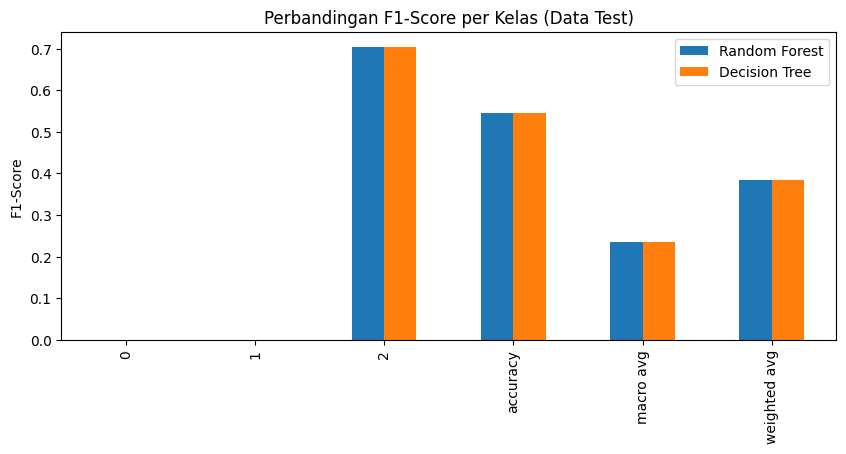

Confusion Matrix Random Forest:
[[   0    0  102]
 [   0    0 6758]
 [   0    0 8193]]
Confusion Matrix Decision Tree:
[[   0    0  102]
 [   0    0 6758]
 [   0    0 8193]]


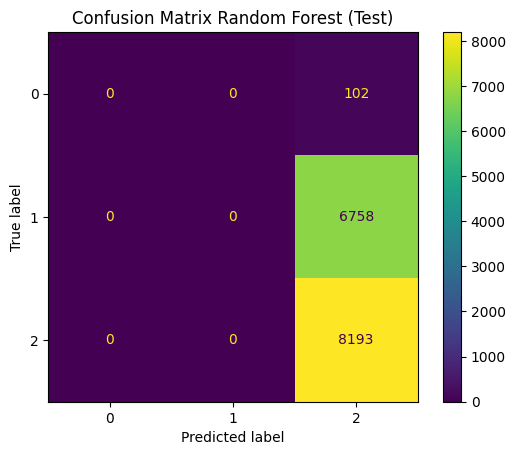

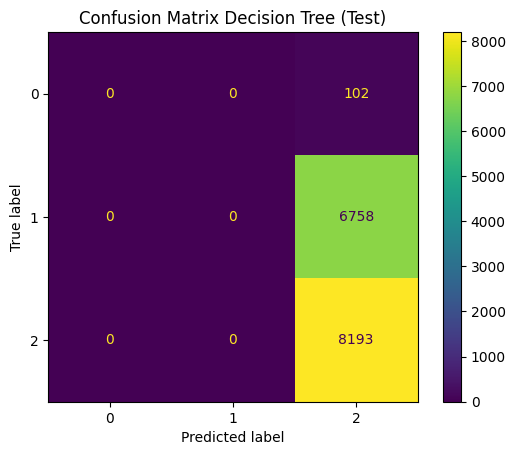

Distribusi prediksi RF (custom threshold): {0: 2, 2: 15051}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       102
           1       0.00      0.00      0.00      6758
           2       0.54      1.00      0.70      8193

    accuracy                           0.54     15053
   macro avg       0.18      0.33      0.23     15053
weighted avg       0.30      0.54      0.38     15053



In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Tambahkan fitur baru ke daftar fitur
extended_features = dummy_features + ['jumlah_ada', 'monitoring_posyandu', 'kategori_anggaran']

# Normalisasi & encoding
df_encoded = normalize_kategorikal(df.copy(), dummy_features)
for col in dummy_features:
    df_encoded[col] = df_encoded[col].where(df_encoded[col].isin(le_dict[col].classes_), le_dict[col].classes_[0])
    df_encoded[col] = le_dict[col].transform(df_encoded[col])

# Encoding fitur baru
from sklearn.preprocessing import LabelEncoder
le_monitoring_posyandu = LabelEncoder()
df_encoded['monitoring_posyandu'] = le_monitoring_posyandu.fit_transform(df['monitoring_posyandu'])
le_kategori_anggaran = LabelEncoder()
df_encoded['kategori_anggaran'] = le_kategori_anggaran.fit_transform(df['kategori_anggaran'])

# jumlah_ada sudah numerik, tidak perlu encoding

X = df_encoded[extended_features]
y = le_label.transform(df['label_efektivitas'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Prediksi pada data test (gunakan hanya fitur yang sesuai training)
X_test_model = X_test[dummy_features]
y_pred_rf_test = model_rf.predict(X_test_model)
y_pred_dt_test = model_dt.predict(X_test_model)

# 3. Classification report
report_rf_test = classification_report(y_test, y_pred_rf_test, output_dict=True, zero_division=0)
report_dt_test = classification_report(y_test, y_pred_dt_test, output_dict=True, zero_division=0)

# 4. Print distribusi prediksi
print("Distribusi prediksi Random Forest (test):", dict(zip(*np.unique(y_pred_rf_test, return_counts=True))))
print("Distribusi prediksi Decision Tree (test):", dict(zip(*np.unique(y_pred_dt_test, return_counts=True))))

# 5. Print F1-score per kelas
f1_rf_test = pd.DataFrame(report_rf_test).transpose()['f1-score']
f1_dt_test = pd.DataFrame(report_dt_test).transpose()['f1-score']
print("\nF1-score Random Forest (test):\n", f1_rf_test)
print("\nF1-score Decision Tree (test):\n", f1_dt_test)

# 6. Plot perbandingan F1-score pada data test
df_comp_test = pd.DataFrame({'Random Forest': f1_rf_test, 'Decision Tree': f1_dt_test})
df_comp_test.plot(kind='bar', figsize=(10,4))
plt.ylabel('F1-Score')
plt.title('Perbandingan F1-Score per Kelas (Data Test)')
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf_test)
cm_dt = confusion_matrix(y_test, y_pred_dt_test)

print("Confusion Matrix Random Forest:")
print(cm_rf)
print("Confusion Matrix Decision Tree:")
print(cm_dt)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Confusion Matrix Random Forest (Test)")
plt.show()

ConfusionMatrixDisplay(cm_dt).plot()
plt.title("Confusion Matrix Decision Tree (Test)")
plt.show()

# Contoh thresholding untuk kelas 0 dan 1
y_proba_rf = model_rf.predict_proba(X_test[dummy_features])
custom_pred_rf = np.full_like(y_test, 2)  # default ke kelas mayoritas

# Misal: jika probabilitas kelas 0 > 0.2, prediksi kelas 0
custom_pred_rf[y_proba_rf[:,0] > 0.2] = 0
# Jika probabilitas kelas 1 > 0.2, prediksi kelas 1
custom_pred_rf[y_proba_rf[:,1] > 0.2] = 1

print("Distribusi prediksi RF (custom threshold):", dict(zip(*np.unique(custom_pred_rf, return_counts=True))))
print(classification_report(y_test, custom_pred_rf, zero_division=0))


In [34]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report

# Training
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
brf.fit(X_train, y_train)

# Prediksi pada data test
y_pred_brf = brf.predict(X_test)

# Evaluasi
print("Distribusi prediksi Balanced RF:", dict(zip(*np.unique(y_pred_brf, return_counts=True))))
print(classification_report(y_test, y_pred_brf, zero_division=0))


Distribusi prediksi Balanced RF: {0: 154, 1: 4799, 2: 10100}
              precision    recall  f1-score   support

           0       0.66      1.00      0.80       102
           1       0.99      0.71      0.83      6758
           2       0.80      0.99      0.89      8193

    accuracy                           0.86     15053
   macro avg       0.82      0.90      0.84     15053
weighted avg       0.89      0.86      0.86     15053



In [35]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.metrics import classification_report

# Training
eec = EasyEnsembleClassifier(n_estimators=10, random_state=42)
eec.fit(X_train, y_train)

# Prediksi pada data test
y_pred_eec = eec.predict(X_test)

# Evaluasi
print("Distribusi prediksi EasyEnsemble:", dict(zip(*np.unique(y_pred_eec, return_counts=True))))
print(classification_report(y_test, y_pred_eec, zero_division=0))


Distribusi prediksi EasyEnsemble: {0: 469, 1: 4799, 2: 9785}
              precision    recall  f1-score   support

           0       0.22      1.00      0.36       102
           1       0.99      0.71      0.83      6758
           2       0.80      0.95      0.87      8193

    accuracy                           0.84     15053
   macro avg       0.67      0.89      0.68     15053
weighted avg       0.88      0.84      0.85     15053



In [36]:
import xgboost as xgb

# Hitung scale_pos_weight untuk setiap kelas (misal multiclass, gunakan class_weights dari sklearn.utils.class_weight)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Training
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    random_state=42,
    scale_pos_weight=class_weights  # untuk multiclass, bisa juga gunakan sample_weight saat fit
)

# Compute sample weights for each sample in y_train
sample_weights = np.array([class_weight_dict[label] for label in y_train])

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Prediksi pada data test
y_pred_xgb = xgb_model.predict(X_test)

# Evaluasi
print("Distribusi prediksi XGBoost:", dict(zip(*np.unique(y_pred_xgb, return_counts=True))))
print(classification_report(y_test, y_pred_xgb, zero_division=0))


Distribusi prediksi XGBoost: {0: 149, 1: 4779, 2: 10125}
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       102
           1       1.00      0.71      0.83      6758
           2       0.80      0.99      0.89      8193

    accuracy                           0.86     15053
   macro avg       0.83      0.90      0.84     15053
weighted avg       0.89      0.86      0.86     15053



In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier

# Pipeline: SMOTE + AdaBoost
smote_ada_pipeline = Pipeline([
	('smote', SMOTE(random_state=42)),
	('ada', AdaBoostClassifier(n_estimators=50, random_state=42))
])

# Training
smote_ada_pipeline.fit(X_train, y_train)

# Prediksi pada data test
y_pred_sb = smote_ada_pipeline.predict(X_test)

# Evaluasi
print("Distribusi prediksi SMOTE+AdaBoost:", dict(zip(*np.unique(y_pred_sb, return_counts=True))))
print(classification_report(y_test, y_pred_sb, zero_division=0))

Distribusi prediksi SMOTE+AdaBoost: {0: 149, 1: 13520, 2: 1384}
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       102
           1       0.50      1.00      0.67      6758
           2       1.00      0.17      0.29      8193

    accuracy                           0.55     15053
   macro avg       0.73      0.72      0.59     15053
weighted avg       0.77      0.55      0.46     15053



In [38]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Training model baru (misal Random Forest)
from sklearn.ensemble import RandomForestClassifier
rf_rus = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rus.fit(X_train_rus, y_train_rus)

# Prediksi pada data test
y_pred_rf_rus = rf_rus.predict(X_test)

# Evaluasi
print("Distribusi prediksi RF (undersample):", dict(zip(*np.unique(y_pred_rf_rus, return_counts=True))))
print(classification_report(y_test, y_pred_rf_rus, zero_division=0))

Distribusi prediksi RF (undersample): {0: 155, 1: 4799, 2: 10099}
              precision    recall  f1-score   support

           0       0.66      1.00      0.79       102
           1       0.99      0.71      0.83      6758
           2       0.80      0.99      0.89      8193

    accuracy                           0.86     15053
   macro avg       0.82      0.90      0.84     15053
weighted avg       0.89      0.86      0.86     15053



## 🧹 Pemeriksaan Missing Values
Menampilkan jumlah nilai yang hilang pada setiap kolom.

In [39]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
a._Total_Remaja_Putri                                                                                                                                 1502
b._Remaja_Putri_Status_Gizi_Normal_di_desa                                                                                                            1502
c._Remaja_Putri_Status_Anemia_(Hb)_di_desa                                                                                                            1502
Total_Calon_Pengantin_dan_calon_Pasangan_usia_Subur_di_desa                                                                                           1502
a._Total_Ibu_Hamil                                                                                                                                    1503
b._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Normal                                                                                                            1503
c._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Kesesah

## 🔗 Analisis Korelasi
Menampilkan korelasi antar variabel numerik dan memvisualisasikannya dalam bentuk heatmap.

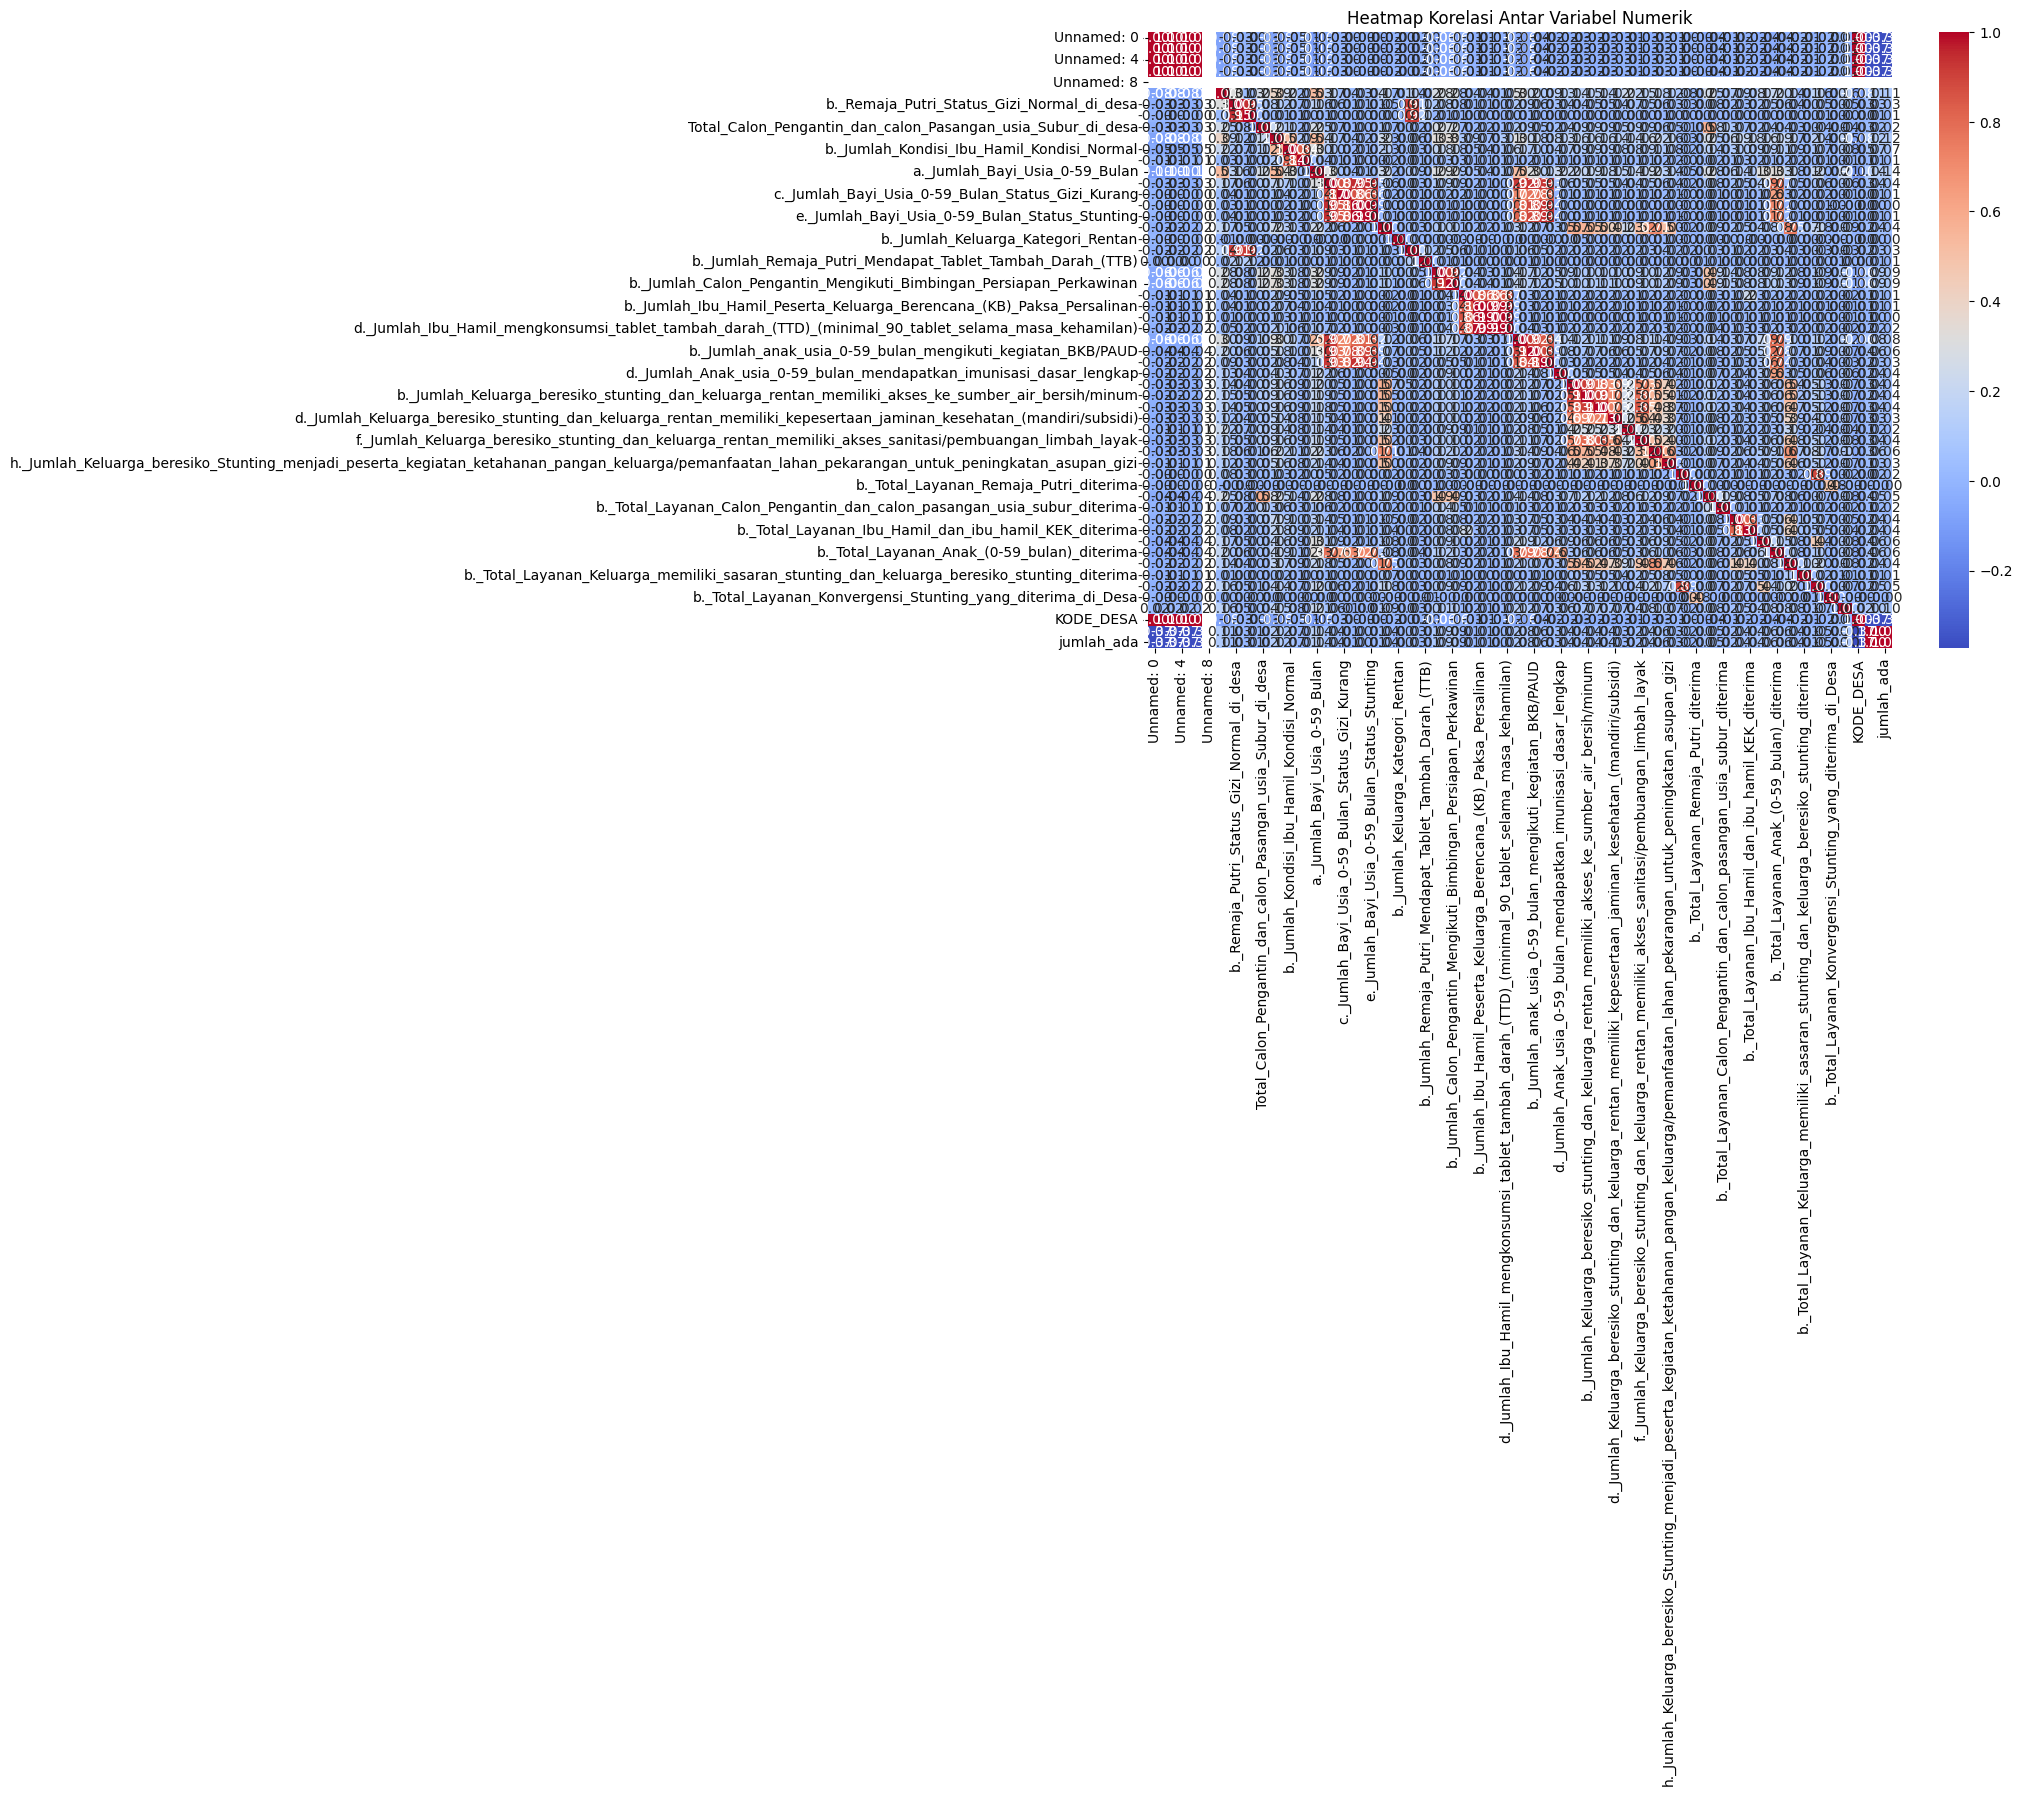

In [40]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Variabel Numerik")
plt.show()

## 📦 Boxplot Anggaran vs Skor Efektivitas
Visualisasi penyebaran anggaran berdasarkan skor efektivitas.

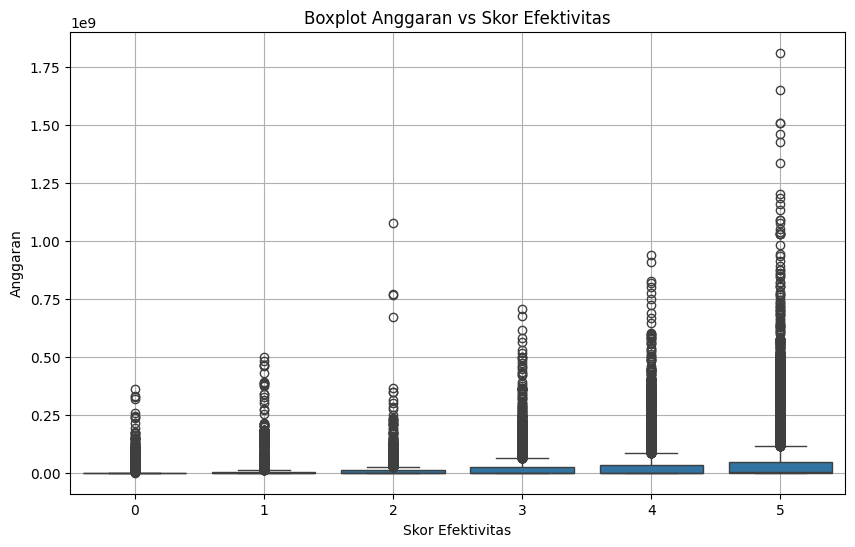

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='skor', y='Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting', data=df)
plt.title("Boxplot Anggaran vs Skor Efektivitas")
plt.xlabel("Skor Efektivitas")
plt.ylabel("Anggaran")
plt.grid(True)
plt.show()

## 🚨 Deteksi Outlier Anggaran
Menggunakan metode IQR untuk mendeteksi outlier pada kolom anggaran.

In [42]:
Q1 = df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'].quantile(0.25)
Q3 = df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'] < lower_bound) | (df['Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'] > upper_bound)]
print(f"Jumlah outlier yang terdeteksi: {len(outliers)}")

Jumlah outlier yang terdeteksi: 7482
